In [49]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
folders = ['artifact', 'fish', 'insect', 
           'leave', 'partial-overlapping-objects', 
           'rounded', 'shadow', 'variable',
           'wormish']

for img_folder in folders:
    folder = Path(f"../data/RODI-DATA/RODI-DATA/Train/{img_folder}")
    
    # Hae kaikki kuvat rekursiivisesti
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    images = [p for p in folder.rglob("*") if p.suffix.lower() in image_extensions]
    
    print(f"Kuvia löytyi {img_folder}: {len(images)}")

Kuvia löytyi artifact: 4459
Kuvia löytyi fish: 357
Kuvia löytyi insect: 2618
Kuvia löytyi leave: 6127
Kuvia löytyi partial-overlapping-objects: 3502
Kuvia löytyi rounded: 623
Kuvia löytyi shadow: 3307
Kuvia löytyi variable: 21785
Kuvia löytyi wormish: 21017


In [40]:
results = pd.read_csv("../outputs/predictions_test.csv")

In [41]:
results['probability'] = round(results['probability'], 2)
results.head()

,img_name,probability
0,250513_0_157_2.jpg,0.0
1,250513_0_164_1.jpg,0.0
2,250513_0_165_1_1.jpg,0.0
3,250513_0_166_1.jpg,0.0
4,250513_0_166_2.jpg,0.0


In [42]:
count = (results['probability'] >= 0.5).sum()
print(count)

360


In [43]:
indices = results.index[results['probability'] >= 0.5].sort_values()
print(indices)

Index([ 3982,  4459,  4460,  4461,  4462,  4463,  4464,  4465,  4466,  4467,
       ...
        4808,  4809,  4810,  4811,  4812,  4813,  4814,  4815, 14941, 15186],
      dtype='int64', length=360)


In [48]:
test_results = pd.read_json("../outputs/training_metrics_model.json")
test_results.head()

,epoch,train_loss,val_loss,val_acc,val_f1,precision_fish,recall_fish,precision_non-fish,Recall_non-fish,AUPRC,AUROC
0,1,0.022260,0.003943,0.999138,0.916031,0.845070,1.000000,1.000000,0.999134,0.987684,0.999942
1,2,0.007933,0.002987,0.999059,0.909091,0.833333,1.000000,1.000000,0.999055,0.995380,0.999978
2,3,0.005241,0.001621,0.999451,0.944000,0.907692,0.983333,0.999921,0.999528,0.997170,0.999986
3,4,0.004290,0.003212,0.999608,0.959350,0.936508,0.983333,0.999921,0.999685,0.962210,0.999904
4,5,0.003122,0.000792,0.999686,0.967742,0.937500,1.000000,1.000000,0.999685,0.998929,0.999995


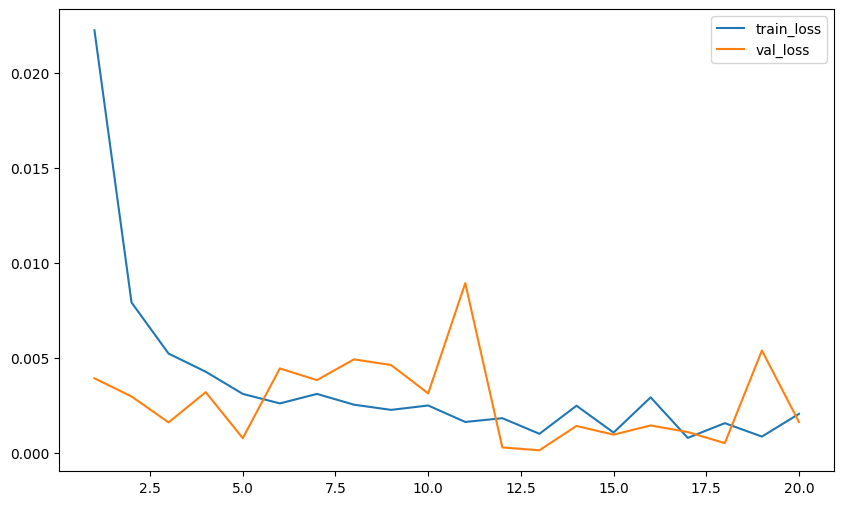

In [54]:
plt.figure(figsize=(10,6))
plt.plot(test_results['epoch'], test_results['train_loss'], label='train_loss')
plt.plot(test_results['epoch'], test_results['val_loss'], label='val_loss')
plt.legend()